# 🔬 HCVRPTW Step-by-Step Training Analysis
Notebook ini dirancang bagi Anda yang ingin membedah bagaimana kode bekerja di balik layar, alih-alih sekadar memanggil `run.py`.
Di sini, kita akan menginisialisasi **Model**, **Baseline**, dan menjalankan **Training Loop (Epoch & Batch)** secara manual step-by-step.

In [21]:
# 1. Setup Environment (Hanya untuk Google Colab)
# Uncomment baris di bawah ini jika baru pertama clone di Colab
# !git clone https://github.com/your-repo/routing-optim.git
# %cd routing-optim/fleet_v3_gcollab
# !pip install -r ../requirements.txt

## 📚 1. Import Dependencies
Mengimpor semua library dan modul lokal yang dibutuhkan (pastikan Anda sudah berada di dalam folder `fleet_v3_gcollab`).

In [1]:
import os
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import math

# Periksa apakah ipywidgets terinstal secara benar untuk menghindari ImportError saat tqdm dijalankan
try:
    from tqdm.notebook import tqdm
    tqdm(range(0)).close()
except (ImportError, NameError, Exception):
    from tqdm import tqdm

# Import dari struktur internal fleet_v3
from core.problems import HCVRP
from core.nets.attention_model import AttentionModelDecoder
from core.reinforce_baselines import RolloutBaseline
from utils import move_to
from core.nets.attention_model import set_decode_type

Exception ignored in: <function tqdm.__del__ at 0x0000021066D60EA0>
Traceback (most recent call last):
  File "c:\Users\kevin.kurniawan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\kevin.kurniawan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


## ⚙️ 2. Konfigurasi Manual (Pengganti `options.py`)
Sebagai pengganti argumen CLI (`--graph_size 40`, dll), kita mendefinisikan kamus opsi secara eksplisit.

In [2]:
import time
class DummyOptions:
    def __init__(self):
        # Default values from options.py to prevent AttributeError
        self._defaults = {
            'problem': 'hcvrp',
            'graph_size': 20,
            'batch_size': 512,
            'epoch_size': 1280000,
            'val_size': 10000,
            'val_dataset': None,
            'obj': 'min-max',
            'model': 'attention_decoder',
            'embedding_dim': 128,
            'hidden_dim': 128,
            'n_encode_layers': 3,
            'tanh_clipping': 10.,
            'normalization': 'batch',
            'lr_model': 1e-4,
            'lr_critic': 1e-4,
            'lr_decay': 0.995,
            'eval_only': False,
            'n_epochs': 50,
            'seed': 1234,
            'max_grad_norm': 3.0,
            'no_cuda': False,
            'exp_beta': 0.8,
            'baseline': None,
            'bl_alpha': 0.05,
            'bl_warmup_epochs': None,
            'eval_batch_size': 1024,
            'checkpoint_encoder': False,
            'shrink_size': None,
            'data_distribution': None,
            'log_step': 50,
            'log_dir': 'logs',
            'run_name': 'run',
            'output_dir': 'outputs',
            'save_dir': 'outputs/hcvrp_20/run', # Fallback default
            'epoch_start': 0,
            'checkpoint_epochs': 1,
            'load_path': None,
            'resume': None,
            'no_tensorboard': False,
            'no_progress_bar': False,
            'n_paths': 5,
            'kl_loss': 0.0,
        }

    def __getattr__(self, name):
        if name in self._defaults:
            return self._defaults[name]
        raise AttributeError(f"'DummyOptions' object has no attribute '{name}'")

opts = DummyOptions()

# =====================================================================
# SELECT PRESET CONFIGURATION (Cukup ganti nilai SELECTED_PRESET di bawah)
# Pilihan:
#   - 'run_testing'       (graph_size=10, decoder, debug)
#   - 'train_implicit'    (graph_size=40, implicit)
#   - 'train_explicit'    (graph_size=40, explicit)
#   - 'train_decoder'     (graph_size=40, decoder)
#   - 'train_multi_decoder'(graph_size=20, multi_decoder)
# =====================================================================
SELECTED_PRESET = 'run_testing' 

PRESETS = {
    'run_testing': {
        'graph_size': 10,
        'batch_size': 3,
        'epoch_size': 3,
        'val_size': 2,
        'n_epochs': 3,
        'lr_model': 1e-4,
        'lr_critic': 1e-4,
        'lr_decay': 0.99,
        'max_grad_norm': 1.0,
        'embedding_dim': 32,
        'hidden_dim': 32,
        'n_encode_layers': 2,
        'tanh_clipping': 10.0,
        'normalization': 'batch',
        'obj': 'min-max',
        'model': 'attention_decoder',
        'baseline': 'rollout',
        'n_paths': 1,
        'checkpoint_encoder': False,
        'shrink_size': None,
        'data_distribution': None,
    },
    'train_implicit': {
        'graph_size': 40,
        'batch_size': 512,
        'epoch_size': 1280000,
        'val_size': 10000,
        'n_epochs': 50,
        'lr_model': 1e-4,
        'lr_critic': 1e-4,
        'lr_decay': 0.995,
        'max_grad_norm': 3.0,
        'embedding_dim': 128,
        'hidden_dim': 128,
        'n_encode_layers': 3,
        'tanh_clipping': 10.0,
        'normalization': 'batch',
        'obj': 'min-max',
        'model': 'attention_implicit',
        'baseline': 'rollout',
        'n_paths': 1,
        'checkpoint_encoder': False,
        'shrink_size': None,
        'data_distribution': None,
    },
    'train_explicit': {
        'graph_size': 40,
        'batch_size': 512,
        'epoch_size': 1280000,
        'val_size': 10000,
        'n_epochs': 50,
        'lr_model': 1e-4,
        'lr_critic': 1e-4,
        'lr_decay': 0.995,
        'max_grad_norm': 3.0,
        'embedding_dim': 128,
        'hidden_dim': 128,
        'n_encode_layers': 3,
        'tanh_clipping': 10.0,
        'normalization': 'batch',
        'obj': 'min-max',
        'model': 'attention_explicit',
        'baseline': 'rollout',
        'n_paths': 1,
        'checkpoint_encoder': False,
        'shrink_size': None,
        'data_distribution': None,
    },
    'train_decoder': {
        'graph_size': 40,
        'batch_size': 512,
        'epoch_size': 1280000,
        'val_size': 10000,
        'n_epochs': 50,
        'lr_model': 1e-4,
        'lr_critic': 1e-4,
        'lr_decay': 0.995,
        'max_grad_norm': 3.0,
        'embedding_dim': 128,
        'hidden_dim': 128,
        'n_encode_layers': 3,
        'tanh_clipping': 10.0,
        'normalization': 'batch',
        'obj': 'min-max',
        'model': 'attention_decoder',
        'baseline': 'rollout',
        'n_paths': 1,
        'checkpoint_encoder': False,
        'shrink_size': None,
        'data_distribution': None,
    },
    'train_multi_decoder': {
        'graph_size': 20,
        'batch_size': 512,
        'epoch_size': 1280000,
        'val_size': 10000,
        'n_epochs': 50,
        'lr_model': 1e-4,
        'lr_critic': 1e-4,
        'lr_decay': 0.995,
        'max_grad_norm': 3.0,
        'embedding_dim': 128,
        'hidden_dim': 128,
        'n_encode_layers': 3,
        'tanh_clipping': 10.0,
        'normalization': 'batch',
        'obj': 'min-max',
        'model': 'attention_multi_decoder',
        'baseline': 'rollout',
        'n_paths': 5,
        'kl_loss': 1.0,
        'checkpoint_encoder': False,
        'shrink_size': None,
        'data_distribution': None,
    }
}

# Terapkan konfigurasi terpilih
config = PRESETS[SELECTED_PRESET]
for key, val in config.items():
    setattr(opts, key, val)

# Setup output directory & run_name secara otomatis
opts.run_name = f"{opts.model}_colab_{time.strftime('%Y%m%dT%H%M%S')}"
opts.save_dir = os.path.join(opts.output_dir, f"{opts.problem}_{opts.graph_size}", opts.run_name)
os.makedirs(opts.save_dir, exist_ok=True)

# Hardware & Evaluasi
opts.use_cuda = torch.cuda.is_available()
opts.device = torch.device('cuda:0' if opts.use_cuda else 'cpu')
opts.eval_batch_size = 4

print(f"Menggunakan Preset: {SELECTED_PRESET}")
print(f"Output directory untuk simpan checkpoint: {opts.save_dir}")
print(f"Device: {opts.device} | Model: {opts.model} | Graph Size: {opts.graph_size}")


Menggunakan Preset: run_testing
Output directory untuk simpan checkpoint: outputs\hcvrp_10\attention_decoder_colab_20260604T104251
Device: cpu | Model: attention_decoder | Graph Size: 10


## 🗺️ 3. Inisialisasi Environment (Problem) & Dataset
Membuat representasi dari masalah Vehicle Routing dengan Time Windows (HCVRPTW).

Dataset HCVRPTW berhasil diinisialisasi.


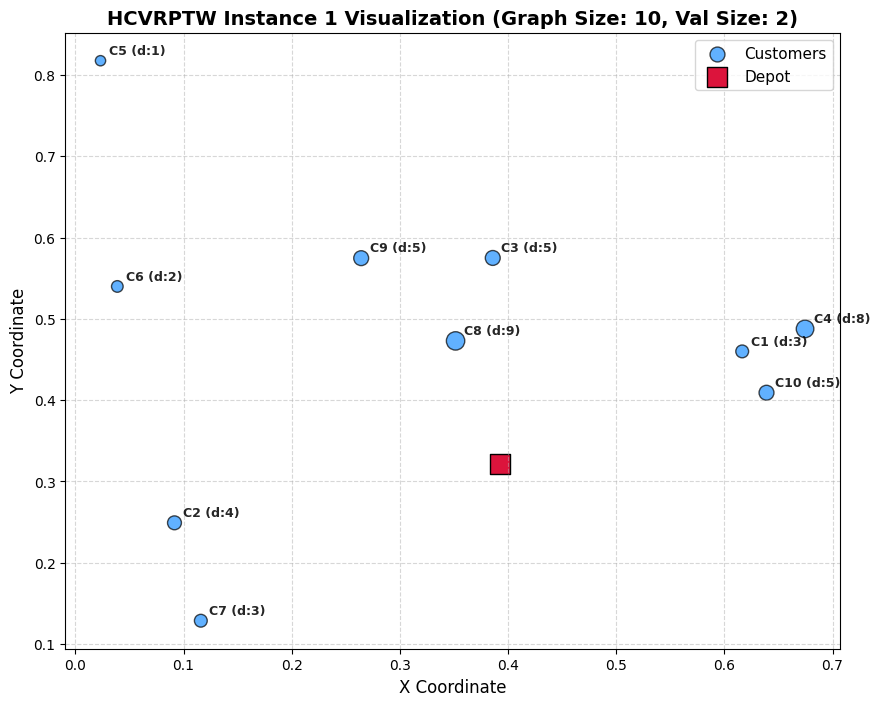

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np

problem = HCVRP()

# Membuat dataset validasi kecil
val_dataset = problem.make_dataset(
    size=opts.graph_size, 
    num_samples=opts.val_size, 
    distribution=opts.data_distribution
)
print("Dataset HCVRPTW berhasil diinisialisasi.")

# --- Visualisasi Dataset (Instance Pertama) ---
first_instance = val_dataset[0]
depot = first_instance['depot'].cpu().numpy() if isinstance(first_instance['depot'], torch.Tensor) else first_instance['depot']
loc = first_instance['loc'].cpu().numpy() if isinstance(first_instance['loc'], torch.Tensor) else first_instance['loc']
demand = first_instance['demand'].cpu().numpy() if isinstance(first_instance['demand'], torch.Tensor) else first_instance['demand']

plt.figure(figsize=(10, 8))
# Plot customer locations (ukuran titik proporsional dengan besarnya demand)
plt.scatter(loc[:, 0], loc[:, 1], c='dodgerblue', label='Customers', alpha=0.7, edgecolors='black', s=demand*15 + 40)
# Plot depot location
plt.scatter(depot[0], depot[1], c='crimson', marker='s', s=200, label='Depot', edgecolors='black')

# Tambahkan nomor indeks dan demand di atas lokasi customer
for idx, (x, y) in enumerate(loc):
    plt.annotate(f"C{idx+1} (d:{int(demand[idx])})", (x + 0.008, y + 0.008), fontsize=9, alpha=0.85, weight='bold')

plt.title(f"HCVRPTW Instance 1 Visualization (Graph Size: {opts.graph_size}, Val Size: {opts.val_size})", fontsize=14, weight='bold')
plt.xlabel("X Coordinate", fontsize=12)
plt.ylabel("Y Coordinate", fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## 🤖 4. Inisialisasi Model Attention & Rollout Baseline
Membangun arsitektur Transformer Encoder-Decoder dan mendefinisikan *baseline* yang digunakan oleh REINFORCE.

In [4]:
# 1. Inisialisasi Model Attention
model = AttentionModelDecoder(
    opts.embedding_dim,
    opts.hidden_dim,
    opts.obj,
    problem,
    n_encode_layers=opts.n_encode_layers,
    mask_inner=True,
    mask_logits=True,
    normalization=opts.normalization,
    tanh_clipping=opts.tanh_clipping,
    checkpoint_encoder=opts.checkpoint_encoder,
    shrink_size=opts.shrink_size,
    n_paths=opts.n_paths,
).to(opts.device)

# 2. Inisialisasi Rollout Baseline
baseline = RolloutBaseline(model, problem, opts)

print("Model dan Baseline berhasil dibuat!")

Evaluating baseline model on evaluation dataset


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  4.96it/s]

Model dan Baseline berhasil dibuat!


## 🎛️ 5. Inisialisasi Optimizer
Mengatur algoritma *Adam* untuk memperbarui bobot model.

In [5]:
optimizer = optim.Adam(
    [{'params': model.parameters(), 'lr': opts.lr_model}]
    + (
        [{'params': baseline.get_learnable_parameters(), 'lr': opts.lr_critic}]
        if len(baseline.get_learnable_parameters()) > 0 else []
    )
)

lr_scheduler = optim.lr_scheduler.LambdaLR(optimizer, lambda epoch: opts.lr_decay ** epoch)
print("Optimizer Siap.")

Optimizer Siap.


## 🔄 6. Menjalankan Training Loop (Bongkar `train.py`)
Di sini kita membedah isi dari `train_epoch` dan `train_batch`. Anda dapat memberikan perintah `print()` atau `display()` di mana saja untuk melihat wujud asli tensor (koordinat, probabilitas) pada setiap *step*.

In [6]:
epoch_costs = []
epoch_losses = []

for epoch in range(opts.n_epochs):
    print(f"\n=== Mulai Epoch {epoch} ===")
    lr_scheduler.step(epoch)
    
    # 1. Generate Training Data baru per epoch
    training_dataset = baseline.wrap_dataset(problem.make_dataset(
        size=opts.graph_size, num_samples=opts.epoch_size, distribution=opts.data_distribution
    ))
    training_dataloader = DataLoader(training_dataset, batch_size=opts.batch_size, num_workers=0)
    
    # 2. Set Model ke mode Training & Sampling (bukan greedy)
    model.train()
    set_decode_type(model, "sampling")
    
    epoch_cost_sum = 0
    epoch_loss_sum = 0
    num_batches = len(training_dataloader)
    
    # 3. Looping Batch
    for batch_id, batch in enumerate(tqdm(training_dataloader, desc=f"Epoch {epoch}")):
        
        # Ekstrak X (Data Input) dan bl_val (Baseline Val)
        x, bl_val = baseline.unwrap_batch(batch)
        x = move_to(x, opts.device)
        bl_val = move_to(bl_val, opts.device) if bl_val is not None else None
        
        # --- FORWARD PASS MODEL ---
        # Di sinilah model mencerna koordinat, demand, dan time windows
        # Mengembalikan: Biaya Rute, Log-Likelihood rute, Log-Likelihood kendaran
        out = model(x, opts=opts)
        
        cost, log_likelihood, log_veh = out[0], out[1], out[2]
        
        # Evaluasi dengan Baseline (Rollout)
        bl_val, bl_loss = baseline.eval(x, cost) if bl_val is None else (bl_val, 0)
        
        # --- PERHITUNGAN LOSS (REINFORCE) ---
        # Formula: (Cost - Baseline) * Log_Probabilitas
        reinforce_loss = ((cost - bl_val) * (log_likelihood + log_veh)).mean()
        loss = reinforce_loss + bl_loss
        
        # --- BACKWARD PASS & OPTIMASI ---
        optimizer.zero_grad()
        loss.backward()
        
        # Memotong gradien (Gradient Clipping) agar bobot tidak "meledak" (exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), opts.max_grad_norm)
        optimizer.step()
        
        epoch_cost_sum += cost.mean().item()
        epoch_loss_sum += loss.item()
        
        if batch_id == 0:
            print(f"[Batch 0] Cost (Distance): {cost.mean().item():.3f} | Loss: {loss.item():.3f}")
            
    # Akhir epoch, uji statistik model melawan baseline
    baseline.epoch_callback(model, epoch)
    
    # Simpan rata-rata cost dan loss per epoch
    epoch_costs.append(epoch_cost_sum / num_batches)
    epoch_losses.append(epoch_loss_sum / num_batches)
    
    # --- SIMPAN CHECKPOINT MODEL ---
    checkpoint_path = os.path.join(opts.save_dir, f'epoch-{epoch}.pt')
    print(f"Menyimpan checkpoint model ke: {checkpoint_path}")
    torch.save(
        {
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'rng_state': torch.get_rng_state(),
            'baseline': baseline.state_dict()
        },
        checkpoint_path
    )


C:\Users\kevin.kurniawan\AppData\Local\Temp\ipykernel_32096\1293893287.py:6: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  lr_scheduler.step(epoch)
C:\Users\kevin.kurniawan\AppData\Local\Temp\ipykernel_32096\1293893287.py:6: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  lr_sche


=== Mulai Epoch 0 ===
Evaluating baseline on dataset...


  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 0: 100%|██████████| 1/1 [00:00<00:00,  2.67it/s]


[Batch 0] Cost (Distance): 2.172 | Loss: -16.147
Evaluating candidate model on evaluation dataset


...

Epoch 1 candidate mean 1.9173619747161865, baseline epoch 0 mean 1.6741943359375, difference 0.24316763877868652
Menyimpan checkpoint model ke: outputs\hcvrp_10\attention_decoder_colab_20260604T104251\epoch-1.pt

=== Mulai Epoch 2 ===
Evaluating baseline on dataset...


Epoch 2: 100%|██████████| 1/1 [00:00<00:00, 11.18it/s]


[Batch 0] Cost (Distance): 2.308 | Loss: -12.668
Evaluating candidate model on evaluation dataset


100%|██████████| 1/1 [00:00<00:00, 24.66it/s]

Epoch 2 candidate mean 1.412332534790039, baseline epoch 0 mean 1.6741943359375, difference -0.26186180114746094
p-value: 0.09971735948813115
Menyimpan checkpoint model ke: outputs\hcvrp_10\attention_decoder_colab_20260604T104251\epoch-2.pt


---
## 🎯 7. Evaluasi Step-by-Step (Inference)
Bagian ini membongkar file `eval.py`. Di sini kita melihat bagaimana model yang sudah dilatih (atau checkpoint yang diload) memberikan keputusan rute (*inference*) secara *Greedy* tanpa menghitung gradien.


In [7]:
from utils import load_model

# A. SETUP EVALUASI
# Jika Anda punya model hasil training, Anda bisa meload-nya dengan cara ini:
# model, _ = load_model('outputs/hcvrp_40/nama_run/epoch-49.pt', opts.obj)

# Pastikan model di mode evaluasi dan tidak menggunakan gradien
model.eval()
model.set_decode_type('greedy') # Mengambil rute dengan probabilitas tertinggi

# B. LOAD DATASET EVALUASI
# Mari gunakan val_dataset yang sudah ada (atau load dataset dari pkl)
eval_dataloader = DataLoader(val_dataset, batch_size=opts.eval_batch_size)

print("Memulai Evaluasi secara Greedy...")
all_costs = []
all_tours = []
all_vehicles = []

with torch.no_grad():
    for batch_id, batch in enumerate(tqdm(eval_dataloader, desc="Evaluasi")):
        batch = move_to(batch, opts.device)
        
        # C. INFERENCE
        # sample_many akan mengevaluasi batch dan mengembalikan [sequences, costs, veh_lists]
        sequences, costs, veh_lists = model.sample_many(batch, batch_rep=1, iter_rep=1)
        
        # Simpan hasilnya
        all_costs.extend(costs.cpu().tolist())
        all_tours.extend(sequences.cpu().tolist())
        all_vehicles.extend(veh_lists.cpu().tolist())
        
        if batch_id == 0:
            print("\n--- CONTOH HASIL PREDIKSI (BATCH PERTAMA) ---")
            print(f"Biaya Rute (Distance/Time): {costs[0].item():.3f}")
            print(f"Urutan Titik (Tour): {sequences[0].tolist()}")
            print(f"Kendaraan yang Dipilih: {veh_lists[0].tolist()}")

print(f"\nEvaluasi Selesai! Rata-rata Cost: {sum(all_costs)/len(all_costs):.3f}")


Memulai Evaluasi secara Greedy...


Evaluasi: 100%|██████████| 1/1 [00:00<00:00, 10.41it/s]


--- CONTOH HASIL PREDIKSI (BATCH PERTAMA) ---
Biaya Rute (Distance/Time): 1.385
Urutan Titik (Tour): [1, 5, 3, 7, 6, 2, 9, 0, 10, 4, 0, 0, 8]
Kendaraan yang Dipilih: [2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 1]

Evaluasi Selesai! Rata-rata Cost: 1.622


## 🔍 8. Analisis Hasil Keputusan Model
Anda bisa langsung menganalisis variabel `all_tours` dan `all_vehicles` di atas untuk melihat pola kendaraan mana yang sering digunakan oleh RL Agent untuk melayani *customer* dengan *time windows* tertentu!
